Previous steps loading.

In [1]:
import pandas as pd 

df = pd.read_csv("../data/processed_fraud_dataset.csv")

df.head()
df.info()

df["is_fraud"].value_counts(normalize=True) * 100

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 12 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   category               1296675 non-null  str    
 1   amt                    1296675 non-null  float64
 2   gender                 1296675 non-null  str    
 3   city_pop               1296675 non-null  int64  
 4   job                    1296675 non-null  str    
 5   is_fraud               1296675 non-null  int64  
 6   transaction_hour       1296675 non-null  int64  
 7   transaction_day        1296675 non-null  int64  
 8   transaction_month      1296675 non-null  int64  
 9   transaction_dayofweek  1296675 non-null  int64  
 10  age                    1296675 non-null  int64  
 11  distance_km            1296675 non-null  float64
dtypes: float64(2), int64(7), str(3)
memory usage: 118.7 MB


is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64

In [2]:
X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

In [3]:
categorical_cols = X.select_dtypes(include=["object"]).columns
numerical_cols = X.select_dtypes(exclude=["object"]).columns

print(categorical_cols)
print(numerical_cols)

Index(['category', 'gender', 'job'], dtype='str')
Index(['amt', 'city_pop', 'transaction_hour', 'transaction_day',
       'transaction_month', 'transaction_dayofweek', 'age', 'distance_km'],
      dtype='str')


C:\Users\vedant\AppData\Local\Temp\ipykernel_13592\4123245944.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns


PART 1 - Feature Importance

Step 1: Load Beat Model

In [4]:
import joblib

xgb_model = joblib.load("../models/best_fraud_model.pkl")

Step 2: Extract Trained XGBoost

In [5]:
xgb_classifier = xgb_model.named_steps["classifier"]

Step 3: Get Feature Names

Because of:
 * OneHotEncoding
 * preprocessing pipeline
feature names became transformed.

Numerical Features

In [6]:
num_features = list(numerical_cols)

Encoded Categorical Features

In [7]:
encoded_cat_features = xgb_model.named_steps[
    "preprocessor"
].named_transformers_["cat"].get_feature_names_out(categorical_cols)

Combine Features

In [8]:
all_features = num_features + list(encoded_cat_features)

Step 4: Feature Importance

In [9]:
import pandas as pd

importance_df = pd.DataFrame({
    "feature": all_features,
    "importance": xgb_classifier.feature_importances_
})

importance_df = importance_df.sort_values(
    by="importance", ascending=False
)

importance_df.head(20)

,feature,importance
12,category_grocery_pos,0.617218
2,transaction_hour,0.142812
21,category_travel,0.066779
0,amt,0.035319
20,category_shopping_pos,0.034752
6,age,0.011644
8,category_entertainment,0.011388
14,category_home,0.006948
19,category_shopping_net,0.004445
16,category_misc_net,0.004385


Step 5: Plot Importance

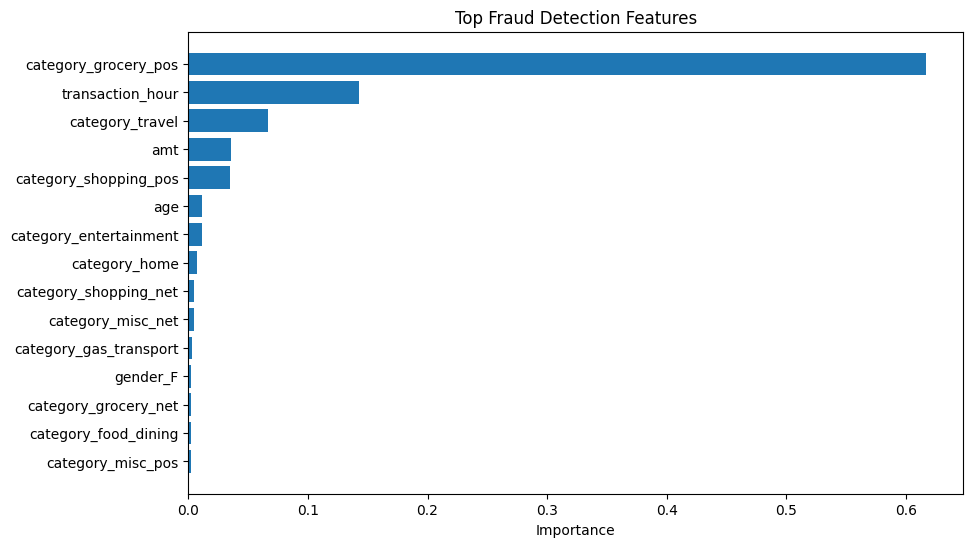

In [10]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15)

plt.figure(figsize=(10,6))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.gca().invert_yaxis()

plt.title("Top Fraud Detection Features")
plt.xlabel("Importance")

plt.show()

PART 2 - SHAP Explainability

Now we move to Explainable AI (XAI)
this is Huge in modern AI systems.

What is SHAP?

SHAP explains: Why the model made a prediction

It breaks prediction into: 
* positive feature contributions
* negative feature contributions

Step 6: Transform Test Data

SHAP needs processed numerical matrix.

In [11]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["is_fraud"])
y = df["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [12]:
X_test_processed = xgb_model.named_steps["preprocessor"].transform(X_test)

Step 7: Create SHAP Explainer

In [13]:
import shap

explainer = shap.TreeExplainer(xgb_classifier)

Step 8: Generate SHAP Values

In [14]:
X_sample = X_test_processed[:1000]

shap_values = explainer.shap_values(X_sample)

Step 9: SHAP Summary Plot

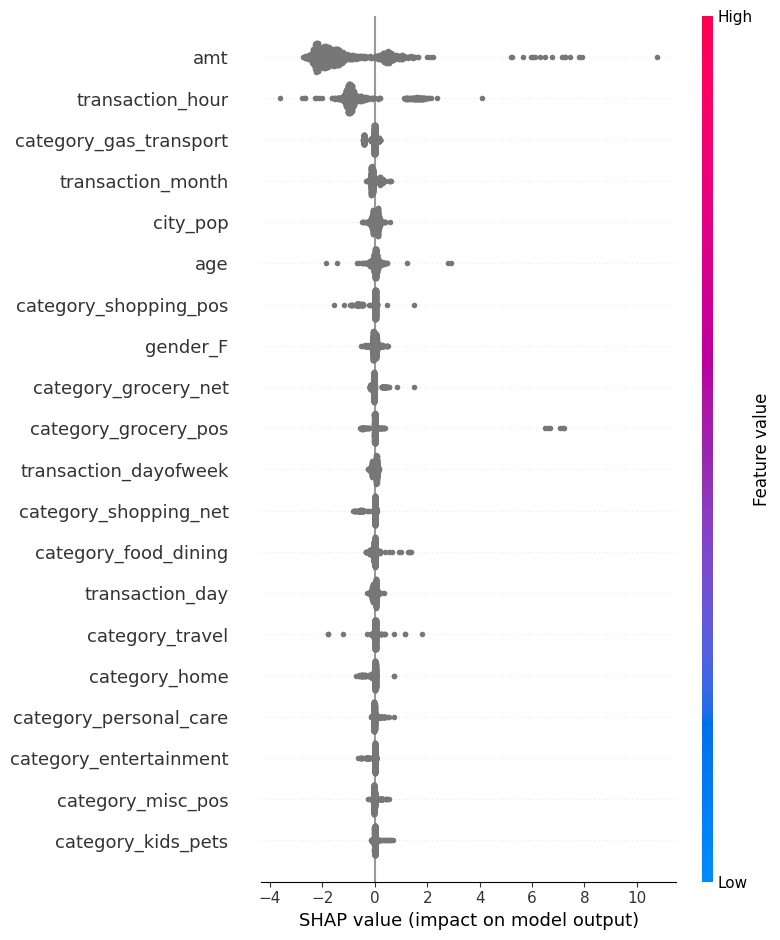

In [15]:
shap.summary_plot(shap_values, X_sample, feature_names=all_features)

PART 3: Explain Individual Fraud Cases

Step 10: Explain Single Prediction

Choose one suspicious transaction:

In [16]:
fraud_index = y_test[y_test == 1].index[0]

Get transformed row:

In [17]:
single_row = xgb_model.named_steps["preprocessor"].transform(X_test.loc[[fraud_index]])

Convert:

In [18]:
single_row_dense = single_row.toarray()

Generate explaination:

In [19]:
single_shap = explainer.shap_values(single_row_dense)

Visualize:

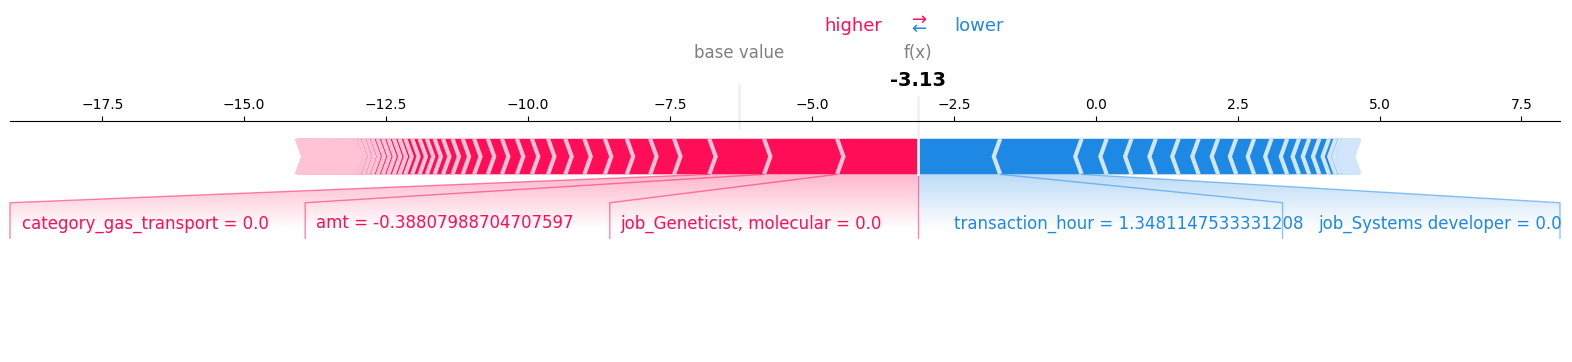

In [20]:
shap.force_plot(explainer.expected_value, single_shap,
 single_row_dense, feature_names=all_features, matplotlib=True)

Part 4: Advanced Feature Engineering

Models learn patterns from features.

In [35]:
import pandas as pd
import numpy as np

raw_df = pd.read_csv("../data/fraudTrain.csv")

raw_df = raw_df.drop(columns=["Unnamed: 0"], errors="ignore")

raw_df["trans_date_trans_time"] = pd.to_datetime(raw_df["trans_date_trans_time"])
raw_df["dob"] = pd.to_datetime(raw_df["dob"])

raw_df["transaction_hour"] = raw_df["trans_date_trans_time"].dt.hour
raw_df["transaction_day"] = raw_df["trans_date_trans_time"].dt.day
raw_df["transaction_month"] = raw_df["trans_date_trans_time"].dt.month
raw_df["transaction_dayofweek"] = raw_df["trans_date_trans_time"].dt.dayofweek

raw_df["age"] = raw_df["trans_date_trans_time"].dt.year - raw_df["dob"].dt.year

Step 11: Transaction Velocity Features

Fraud often involves: 
- rapid transactions
- burst behaviour

Transactions per User

In [36]:
raw_df["transactions_per_user"] = raw_df.groupby("cc_num")["cc_num"].transform("count")
raw_df["avg_amt_per_user"] = raw_df.groupby("cc_num")["amt"].transform("mean")
raw_df["amt_deviation"] = raw_df["amt"] - raw_df["avg_amt_per_user"]

Step 12: Merchant Fraud Rate

In [37]:
merchant_fraud_rate = raw_df.groupby("merchant")[
    "is_fraud"
].mean()

raw_df["merchant_risk"] = raw_df["merchant"].map(
    merchant_fraud_rate
)

Now merchant becomes: Statistical Fraud Signal, instead of raw text.

Step 13: Hourly Fraud Risk

In [38]:
hourly_risk = raw_df.groupby("transaction_hour")["is_fraud"].mean()

raw_df["hourly_risk"] = raw_df["transaction_hour"].map(hourly_risk)

Now model learns:
- night fraud patterns
- suspicious time windows

Step 14: Retrain XGBoost

Now retrain with new engineered features.

This usually improves:
- recall
- fraud intelligence
- separability